# NYC Parking Violations: Exploratory Analysis and Visualizations

This notebook uses the project SQLite database to answer three questions:

1. How did parking ticket volume change during NYC fiscal year 2025?
2. Which violation types produced the most tickets?
3. How did ticket activity vary by month and day of week?

The analysis window is July 1, 2024 through June 30, 2025. Restricting the queries to the official fiscal-year window prevents invalid or legacy issue dates from distorting the results. The source contains substantial volume from July through November 2024 but only a handful of later records, so sparse months are reported as a coverage limitation and excluded from month-to-month comparisons.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

## Connect to the database

The path logic works when the notebook is launched from either the project root or the `notebooks` directory.

In [2]:
STARTING_DIR = Path.cwd()
PROJECT_ROOT = STARTING_DIR if (STARTING_DIR / "data").exists() else STARTING_DIR.parent
DATABASE_FILE = PROJECT_ROOT / "data" / "database" / "nyc_parking.sqlite"

if not DATABASE_FILE.exists():
    raise FileNotFoundError(
        f"Database not found at {DATABASE_FILE}. Run notebook 02 first."
    )

connection = sqlite3.connect(DATABASE_FILE)
FY_START = "2024-07-01"
FY_END = "2025-06-30"
print(f"Database: {DATABASE_FILE}")
print(f"Analysis window: {FY_START} through {FY_END}")

Database: C:\Users\jayson.coker\Documents\nyc-parking-analytics\data\database\nyc_parking.sqlite
Analysis window: 2024-07-01 through 2025-06-30


## Data-quality check

The source is labeled fiscal year 2025, but administrative files can contain corrected, late, or invalid dates. This check reports how many rows fall inside and outside the intended analysis window. A later monthly coverage check prevents months with only a few records from being treated as complete.

In [3]:
date_quality = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN issue_date BETWEEN ? AND ? THEN 1 ELSE 0 END) AS fy2025_rows,
        SUM(CASE WHEN issue_date < ? OR issue_date > ? THEN 1 ELSE 0 END) AS excluded_date_rows,
        MIN(issue_date) AS earliest_issue_date,
        MAX(issue_date) AS latest_issue_date
    FROM parking_violations
    """,
    connection,
    params=(FY_START, FY_END, FY_START, FY_END),
)
date_quality

,total_rows,fy2025_rows,excluded_date_rows,earliest_issue_date,latest_issue_date
0,7056788,6752056,304732,2000-06-03,2025-12-01


## 1. Monthly ticket trend

A line chart makes changes over time easy to see. The SQL query aggregates millions of ticket rows into twelve monthly totals before Pandas receives the data.

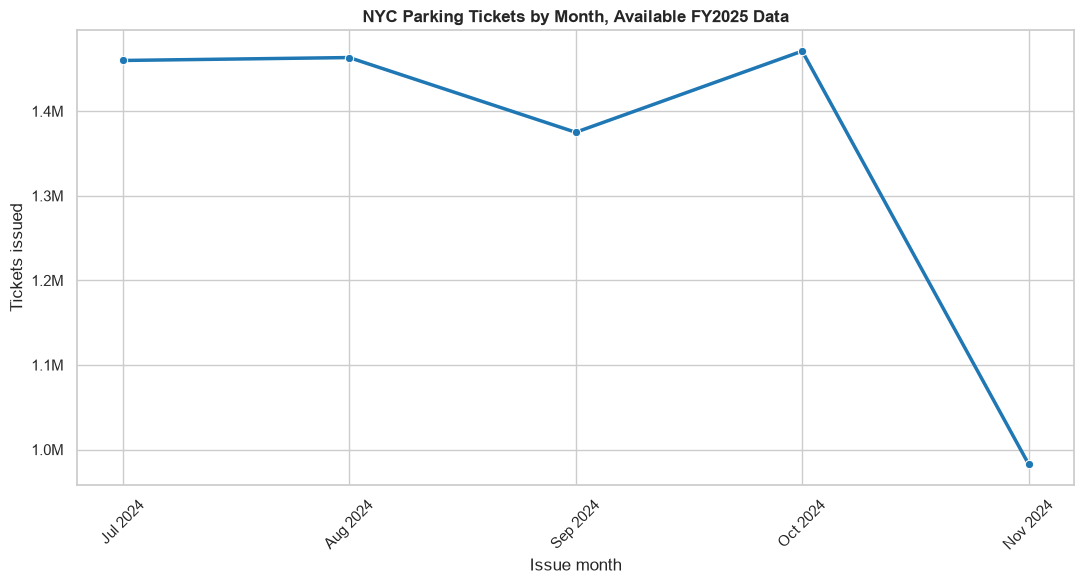

Finding: Oct 2024 had the most tickets (1,470,983), while Nov 2024 had the fewest among months with substantial coverage (982,608).
Coverage note: months with fewer than 1,000 records were excluded from the comparison: Dec 2024, Jan 2025, Feb 2025, Mar 2025, May 2025, Jun 2025


In [4]:
monthly_tickets = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m', issue_date) AS issue_month,
        COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
    GROUP BY strftime('%Y-%m', issue_date)
    ORDER BY issue_month
    """,
    connection,
    params=(FY_START, FY_END),
)
monthly_tickets["month_label"] = pd.to_datetime(
    monthly_tickets["issue_month"]
).dt.strftime("%b %Y")
complete_months = monthly_tickets[monthly_tickets["ticket_count"] >= 1_000].copy()
sparse_months = monthly_tickets[monthly_tickets["ticket_count"] < 1_000].copy()

ax = sns.lineplot(
    data=complete_months,
    x="month_label",
    y="ticket_count",
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
)
ax.set(
    title="NYC Parking Tickets by Month, Available FY2025 Data",
    xlabel="Issue month",
    ylabel="Tickets issued",
)
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(lambda value, _: f"{value / 1_000_000:.1f}M")
plt.tight_layout()
plt.show()

peak_month = complete_months.loc[complete_months["ticket_count"].idxmax()]
low_month = complete_months.loc[complete_months["ticket_count"].idxmin()]
print(
    f"Finding: {peak_month['month_label']} had the most tickets "
    f"({peak_month['ticket_count']:,}), while {low_month['month_label']} "
    f"had the fewest among months with substantial coverage "
    f"({low_month['ticket_count']:,})."
)
print(
    "Coverage note: months with fewer than 1,000 records were excluded from "
    "the comparison: "
    + ", ".join(sparse_months["month_label"])
)

## 2. Most common violation types

This query joins the parking fact table to the violation lookup dimension. A horizontal bar chart leaves enough room for the violation descriptions.

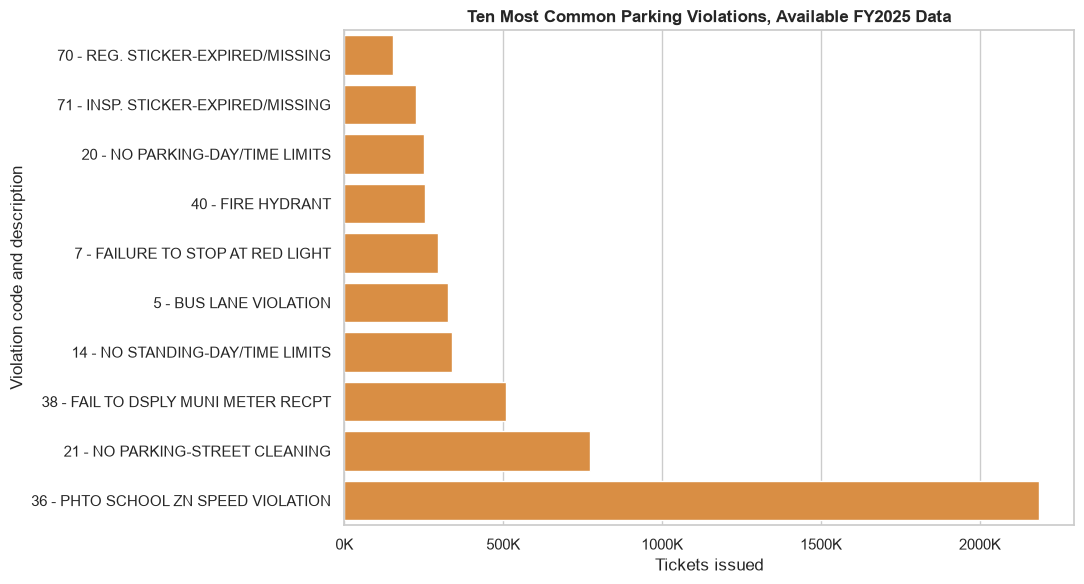

Finding: violation code 36 was the most common with 2,186,706 tickets. The top ten codes together accounted for 78.6% of in-window tickets.


In [5]:
top_violations = pd.read_sql_query(
    """
    SELECT
        p.violation_code,
        COALESCE(v.violation_description, 'Description unavailable') AS violation_description,
        COUNT(*) AS ticket_count
    FROM parking_violations AS p
    LEFT JOIN violation_lookup AS v
        ON v.violation_code = p.violation_code
    WHERE p.issue_date BETWEEN ? AND ?
    GROUP BY p.violation_code, v.violation_description
    ORDER BY ticket_count DESC
    LIMIT 10
    """,
    connection,
    params=(FY_START, FY_END),
)
top_violations["label"] = (
    top_violations["violation_code"].astype("Int64").astype(str)
    + " - "
    + top_violations["violation_description"].str.slice(0, 48)
)

plot_data = top_violations.sort_values("ticket_count")
ax = sns.barplot(
    data=plot_data,
    x="ticket_count",
    y="label",
    color="#f28e2b",
)
ax.set(
    title="Ten Most Common Parking Violations, Available FY2025 Data",
    xlabel="Tickets issued",
    ylabel="Violation code and description",
)
ax.xaxis.set_major_formatter(lambda value, _: f"{value / 1_000:.0f}K")
plt.tight_layout()
plt.show()

leader = top_violations.iloc[0]
top_share = top_violations["ticket_count"].sum() / date_quality.loc[0, "fy2025_rows"]
print(
    f"Finding: violation code {int(leader['violation_code'])} was the most common "
    f"with {leader['ticket_count']:,} tickets. The top ten codes together "
    f"accounted for {top_share:.1%} of in-window tickets."
)

## 3. Month and weekday pattern

The heatmap compares two time dimensions at once. Each cell shows the number of tickets issued for a weekday during a fiscal-year month.

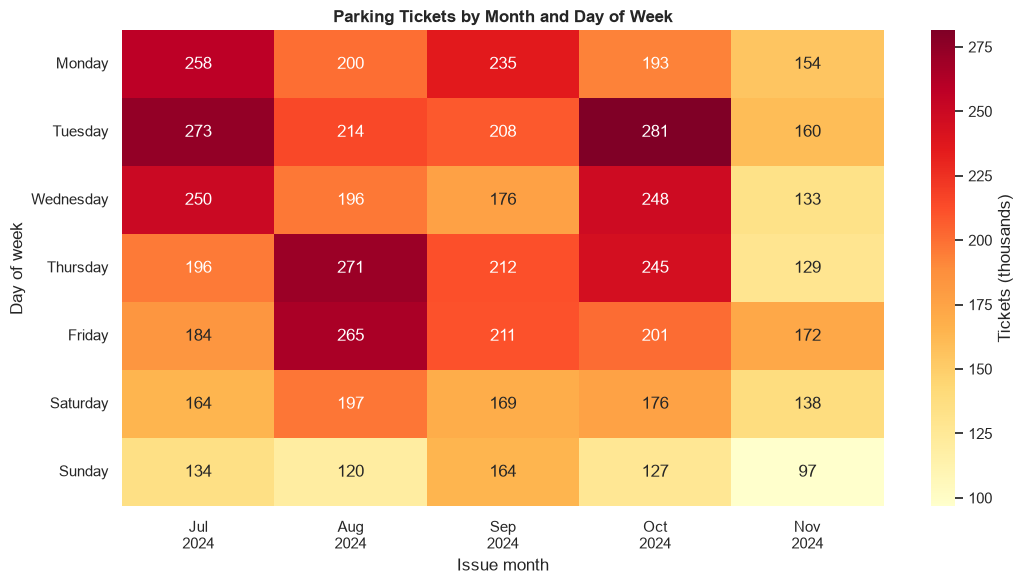

Finding: Tuesday had the highest total ticket volume, while Sunday had the lowest.


In [6]:
weekday_month = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m', issue_date) AS issue_month,
        issue_day_of_week,
        issue_day_name,
        COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
    GROUP BY strftime('%Y-%m', issue_date), issue_day_of_week, issue_day_name
    ORDER BY issue_month, issue_day_of_week
    """,
    connection,
    params=(FY_START, FY_END),
)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = complete_months["issue_month"].tolist()
heatmap_data = weekday_month.pivot_table(
    index="issue_day_name",
    columns="issue_month",
    values="ticket_count",
    aggfunc="sum",
).reindex(index=weekday_order, columns=month_order)
heatmap_data.columns = pd.to_datetime(heatmap_data.columns).strftime("%b\n%Y")

ax = sns.heatmap(
    heatmap_data / 1_000,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Tickets (thousands)"},
)
ax.set(
    title="Parking Tickets by Month and Day of Week",
    xlabel="Issue month",
    ylabel="Day of week",
)
plt.tight_layout()
plt.show()

weekday_totals = weekday_month.groupby("issue_day_name")["ticket_count"].sum()
busiest_day = weekday_totals.idxmax()
quietest_day = weekday_totals.idxmin()
print(
    f"Finding: {busiest_day} had the highest total ticket volume, while "
    f"{quietest_day} had the lowest."
)

## 4. Vehicle attributes and similarities

The parking source contains `vehicle_make`, `vehicle_color`, `vehicle_year`, and `vehicle_body_type`. It does **not** contain a vehicle model field, so this analysis does not infer models from the other attributes.

Vehicle makes and body types are administrative abbreviations such as `TOYOT` for Toyota and `SUBN` for suburban/SUV. Colors appear as both codes and words, so common values are standardized before comparison.

In [7]:
vehicle_completeness = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS ticket_rows,
        SUM(CASE WHEN vehicle_make IS NOT NULL AND TRIM(vehicle_make) <> '' THEN 1 ELSE 0 END) AS rows_with_make,
        SUM(CASE WHEN vehicle_color IS NOT NULL AND TRIM(vehicle_color) <> '' THEN 1 ELSE 0 END) AS rows_with_color,
        SUM(CASE WHEN vehicle_year BETWEEN 1980 AND 2025 THEN 1 ELSE 0 END) AS rows_with_valid_year,
        SUM(CASE WHEN vehicle_body_type IS NOT NULL AND TRIM(vehicle_body_type) <> '' THEN 1 ELSE 0 END) AS rows_with_body_type
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
    """,
    connection,
    params=(FY_START, FY_END),
)
vehicle_completeness

,ticket_rows,rows_with_make,rows_with_color,rows_with_valid_year,rows_with_body_type
0,6752056,6745545,6081928,5566160,6735913


### Most common vehicle makes

This chart counts ticket records, not unique vehicles. A vehicle can appear more than once if it received multiple tickets.

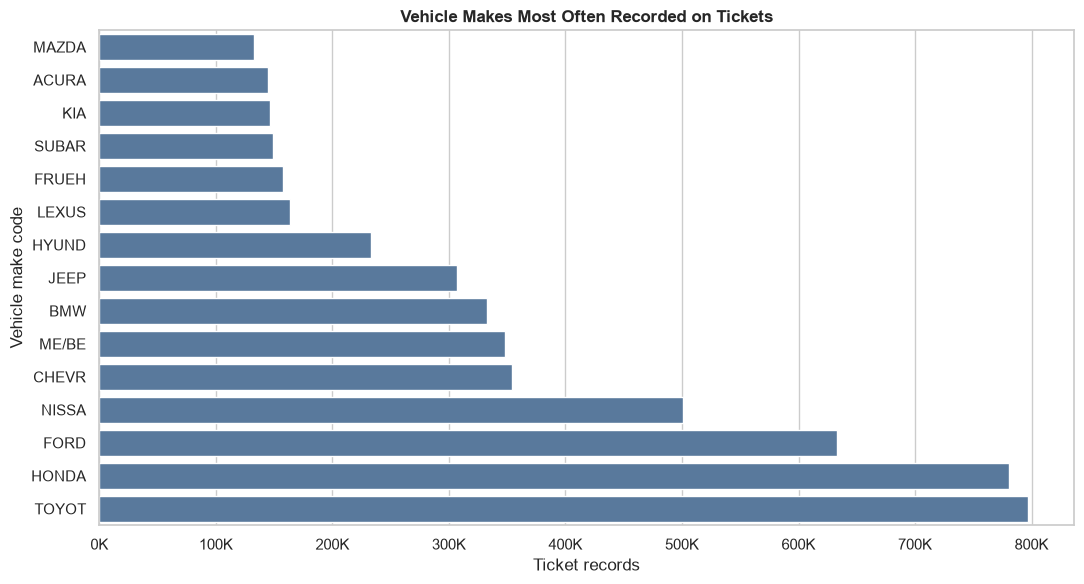

Finding: TOYOT was the most frequently recorded make, appearing on 796,594 tickets.


In [8]:
top_makes = pd.read_sql_query(
    """
    SELECT vehicle_make, COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
      AND vehicle_make IS NOT NULL
      AND TRIM(vehicle_make) <> ''
    GROUP BY vehicle_make
    ORDER BY ticket_count DESC
    LIMIT 15
    """,
    connection,
    params=(FY_START, FY_END),
)

ax = sns.barplot(
    data=top_makes.sort_values("ticket_count"),
    x="ticket_count",
    y="vehicle_make",
    color="#4e79a7",
)
ax.set(
    title="Vehicle Makes Most Often Recorded on Tickets",
    xlabel="Ticket records",
    ylabel="Vehicle make code",
)
ax.xaxis.set_major_formatter(lambda value, _: f"{value / 1_000:.0f}K")
plt.tight_layout()
plt.show()

print(
    f"Finding: {top_makes.iloc[0]['vehicle_make']} was the most frequently "
    f"recorded make, appearing on {top_makes.iloc[0]['ticket_count']:,} tickets."
)

### Standardized vehicle colors

The same color can be entered several ways. For example, `GY`, `GREY`, `GRAY`, and `GRY` are grouped as Gray. Less common or ambiguous codes remain in Other.

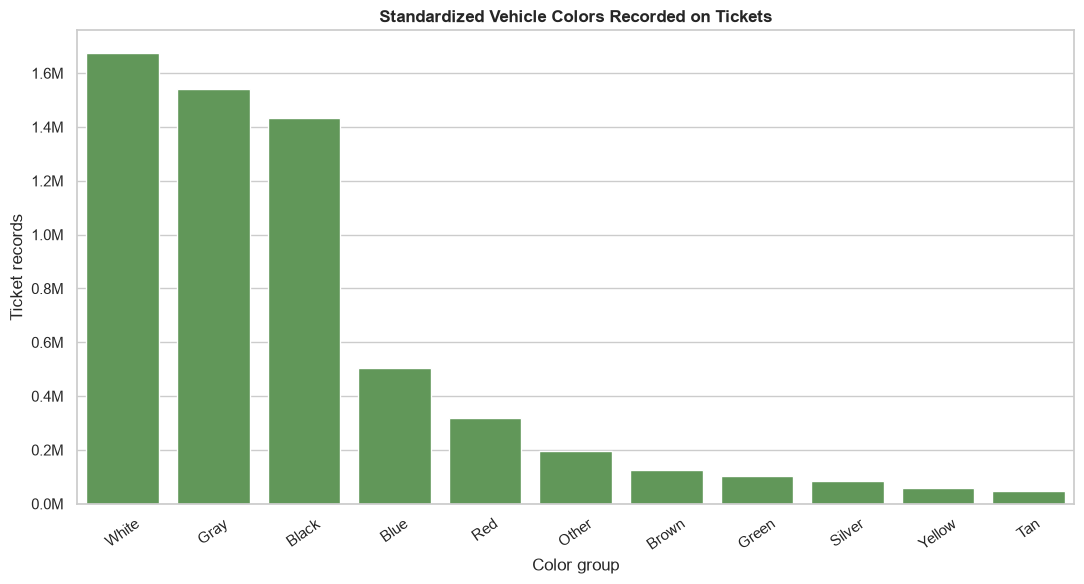

In [9]:
color_case = """
    CASE UPPER(TRIM(vehicle_color))
        WHEN 'GY' THEN 'Gray' WHEN 'GREY' THEN 'Gray' WHEN 'GRAY' THEN 'Gray' WHEN 'GRY' THEN 'Gray'
        WHEN 'WH' THEN 'White' WHEN 'WHITE' THEN 'White' WHEN 'WHI' THEN 'White'
        WHEN 'BK' THEN 'Black' WHEN 'BLACK' THEN 'Black' WHEN 'BLK' THEN 'Black'
        WHEN 'BL' THEN 'Blue' WHEN 'BLUE' THEN 'Blue'
        WHEN 'RD' THEN 'Red' WHEN 'RED' THEN 'Red'
        WHEN 'BR' THEN 'Brown' WHEN 'BROWN' THEN 'Brown'
        WHEN 'GR' THEN 'Green' WHEN 'GREEN' THEN 'Green'
        WHEN 'SILVE' THEN 'Silver' WHEN 'SILVER' THEN 'Silver' WHEN 'SL' THEN 'Silver'
        WHEN 'YW' THEN 'Yellow' WHEN 'YELLOW' THEN 'Yellow' WHEN 'YELLO' THEN 'Yellow'
        WHEN 'TN' THEN 'Tan' WHEN 'TAN' THEN 'Tan'
        ELSE 'Other'
    END
"""

vehicle_colors = pd.read_sql_query(
    f"""
    SELECT {color_case} AS vehicle_color_group, COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
      AND vehicle_color IS NOT NULL
      AND TRIM(vehicle_color) <> ''
    GROUP BY vehicle_color_group
    ORDER BY ticket_count DESC
    """,
    connection,
    params=(FY_START, FY_END),
)

ax = sns.barplot(
    data=vehicle_colors,
    x="vehicle_color_group",
    y="ticket_count",
    color="#59a14f",
)
ax.set(
    title="Standardized Vehicle Colors Recorded on Tickets",
    xlabel="Color group",
    ylabel="Ticket records",
)
ax.tick_params(axis="x", rotation=35)
ax.yaxis.set_major_formatter(lambda value, _: f"{value / 1_000_000:.1f}M")
plt.tight_layout()
plt.show()

### Vehicle model years

A value of zero is common in the source and means the year was unavailable, so only plausible years from 1980 through 2025 are charted.

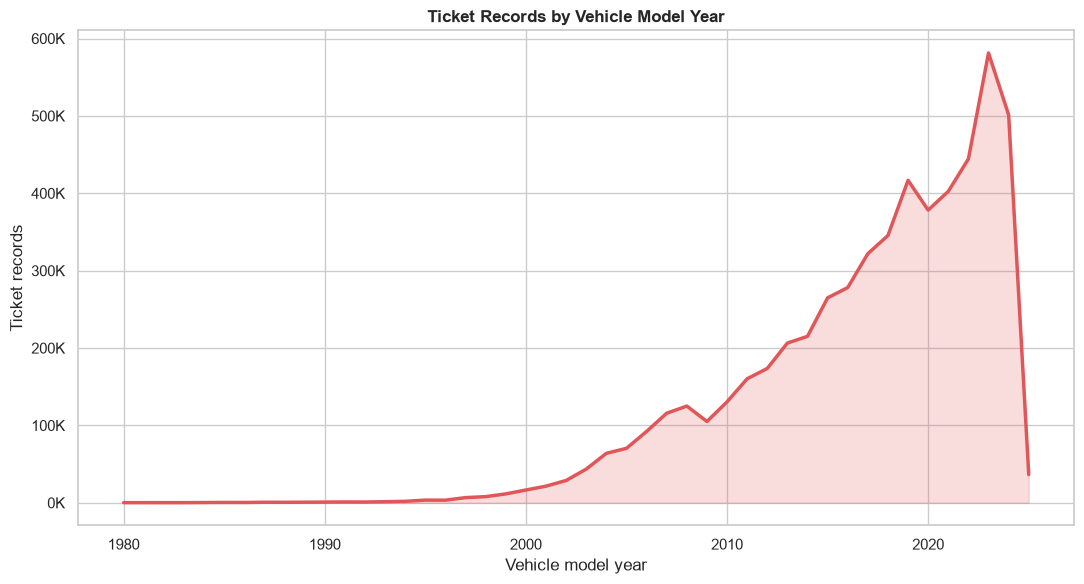

Finding: model year 2023 appeared most often among records with plausible years (581,323 tickets).


In [10]:
vehicle_years = pd.read_sql_query(
    """
    SELECT vehicle_year, COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
      AND vehicle_year BETWEEN 1980 AND 2025
    GROUP BY vehicle_year
    ORDER BY vehicle_year
    """,
    connection,
    params=(FY_START, FY_END),
)

ax = sns.lineplot(
    data=vehicle_years,
    x="vehicle_year",
    y="ticket_count",
    color="#e15759",
    linewidth=2.5,
)
ax.fill_between(
    vehicle_years["vehicle_year"],
    vehicle_years["ticket_count"],
    alpha=0.2,
    color="#e15759",
)
ax.set(
    title="Ticket Records by Vehicle Model Year",
    xlabel="Vehicle model year",
    ylabel="Ticket records",
)
ax.yaxis.set_major_formatter(lambda value, _: f"{value / 1_000:.0f}K")
plt.tight_layout()
plt.show()

peak_year = vehicle_years.loc[vehicle_years["ticket_count"].idxmax()]
print(
    f"Finding: model year {int(peak_year['vehicle_year'])} appeared most often "
    f"among records with plausible years ({peak_year['ticket_count']:,} tickets)."
)

### Similarities between make and color

The heatmap shows which standardized colors occur most often for the eight most frequently ticketed makes. Values are ticket records in thousands.

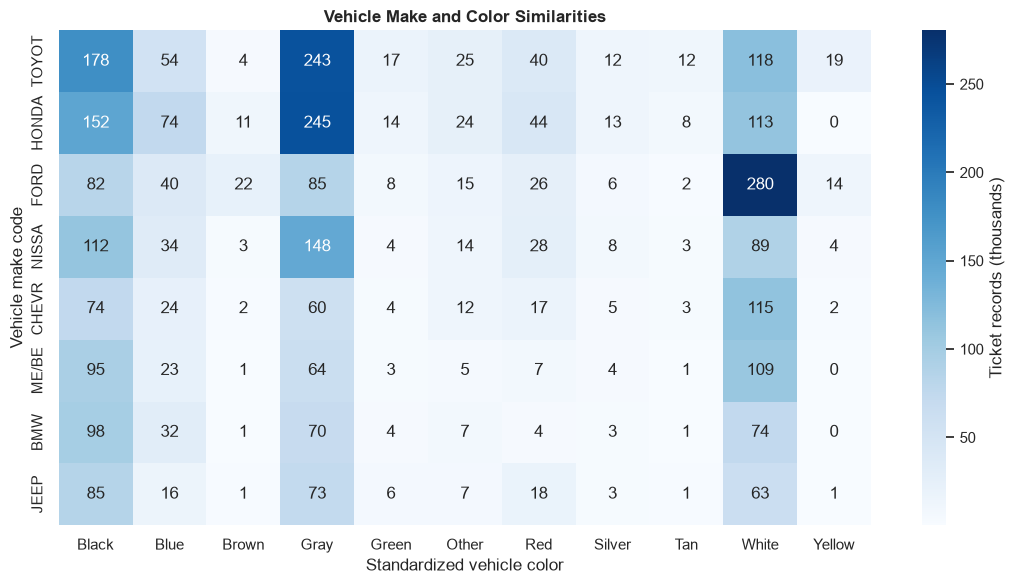

In [11]:
top_make_list = top_makes.head(8)["vehicle_make"].tolist()
placeholders = ", ".join("?" for _ in top_make_list)
make_color = pd.read_sql_query(
    f"""
    SELECT
        vehicle_make,
        {color_case} AS vehicle_color_group,
        COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
      AND vehicle_make IN ({placeholders})
      AND vehicle_color IS NOT NULL
      AND TRIM(vehicle_color) <> ''
    GROUP BY vehicle_make, vehicle_color_group
    """,
    connection,
    params=(FY_START, FY_END, *top_make_list),
)
make_color_matrix = make_color.pivot_table(
    index="vehicle_make",
    columns="vehicle_color_group",
    values="ticket_count",
    aggfunc="sum",
    fill_value=0,
).reindex(top_make_list)

ax = sns.heatmap(
    make_color_matrix / 1_000,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Ticket records (thousands)"},
)
ax.set(
    title="Vehicle Make and Color Similarities",
    xlabel="Standardized vehicle color",
    ylabel="Vehicle make code",
)
plt.tight_layout()
plt.show()

### Most common combined vehicle profiles

This final table combines make, standardized color, plausible model year, and body type. It is the closest available view to a make/model/color/year profile because the source does not include model.

In [12]:
vehicle_profiles = pd.read_sql_query(
    f"""
    SELECT
        vehicle_make,
        {color_case} AS vehicle_color_group,
        vehicle_year,
        vehicle_body_type,
        COUNT(*) AS ticket_count
    FROM parking_violations
    WHERE issue_date BETWEEN ? AND ?
      AND vehicle_make IS NOT NULL
      AND vehicle_color IS NOT NULL
      AND vehicle_year BETWEEN 1980 AND 2025
      AND vehicle_body_type IS NOT NULL
    GROUP BY vehicle_make, vehicle_color_group, vehicle_year, vehicle_body_type
    ORDER BY ticket_count DESC
    LIMIT 25
    """,
    connection,
    params=(FY_START, FY_END),
)
vehicle_profiles

,vehicle_make,vehicle_color_group,vehicle_year,vehicle_body_type,ticket_count
0,FORD,White,2023,VAN,16133
1,FORD,White,2019,VAN,12064
2,TOYOT,Gray,2021,SUBN,11958
3,FORD,White,2020,VAN,11876
4,FORD,White,2017,VAN,11808
5,HONDA,Gray,2024,SUBN,11079
6,TOYOT,Gray,2022,SUBN,10701
7,HONDA,Gray,2022,SUBN,10638
8,TOYOT,Gray,2023,SUBN,10606
9,TESLA,Black,2023,SUBN,10020


## Conclusions

- Monthly totals show how enforcement volume changed across the five months with substantial source coverage.
- The violation ranking shows which behaviors account for the largest share of tickets.
- The heatmap identifies recurring weekday patterns and the months in which those patterns were strongest.
- Vehicle make, standardized color, valid model year, and body type reveal recurring vehicle profiles among ticket records.
- Vehicle model is not available in the source and is not inferred.
- Results are filtered to the official fiscal-year window because out-of-window issue dates exist in the source.
- December 2024 through June 2025 are too sparse for responsible month-to-month comparison, so the notebook documents but does not interpret those months.

These views describe ticket activity, not the number of unique drivers or vehicles. The dataset records issued violations, and the listed violation descriptions come from the project lookup table.

In [13]:
connection.close()